<a href="https://colab.research.google.com/github/DenisDrobyshev/universum/blob/master/vla_into.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Sun Mar 22 13:00:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# https://huggingface.co/docs/lerobot/smolvla

In [ ]:
!git clone https://github.com/huggingface/lerobot.git

Cloning into 'lerobot'...
remote: Enumerating objects: 43219, done.
remote: Counting objects: 100% (362/362), done.
remote: Compressing objects: 100% (232/232), done.
remote: Total 43219 (delta 240), reused 130 (delta 130), pack-reused 42857 (from 5)
Receiving objects: 100% (43219/43219), 235.95 MiB | 31.62 MiB/s, done.
Resolving deltas: 100% (27358/27358), done.
Filtering content: 100% (45/45), 69.03 MiB | 14.50 MiB/s, done.


In [ ]:
!pip install -e "./lerobot[smolvla]"

In [ ]:
!pip install -e "./lerobot[libero]"

In [ ]:
# ! lerobot-eval \
#   --policy.path="HuggingFaceVLA/smolvla_libero" \
#   --env.type=libero \
#   --env.task=libero_object \
#   --eval.batch_size=1 \
#   --eval.n_episodes=3

# Evaluation on LIBERO

In [ ]:
import math
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv

from lerobot.envs.configs import LiberoEnv
from lerobot.configs.policies import PreTrainedConfig
from lerobot.policies.factory import make_policy, make_pre_post_processors
from lerobot.utils.device_utils import get_safe_torch_device
from lerobot.utils.random_utils import set_seed

MODEL_ID = "HuggingFaceVLA/smolvla_libero"

TASK_SUITE_NAME = "libero_spatial"   # or libero_object / libero_goal / libero_10 / libero_90
TASK_ID = 0
INIT_STATE_ID = 0

ENV_IMAGE_SIZE = 256
MAX_STEPS = 220
NUM_STABILIZATION_STEPS = 10
SEED = 42

FRAME_EVERY = 40

Do you want to specify a custom path for the dataset folder? (Y/N): n


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.12/dist-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


Initializing the default config file...
The following information is stored in the config file: /root/.libero/config.yaml
benchmark_root: /usr/local/lib/python3.12/dist-packages/libero/libero
bddl_files: /usr/local/lib/python3.12/dist-packages/libero/libero/./bddl_files
init_states: /usr/local/lib/python3.12/dist-packages/libero/libero/./init_files
datasets: /usr/local/lib/python3.12/dist-packages/libero/libero/../datasets
assets: /usr/local/lib/python3.12/dist-packages/libero/libero/./assets


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
benchmark

<module 'libero.libero.benchmark' from '/usr/local/lib/python3.12/dist-packages/libero/libero/benchmark/__init__.py'>

In [ ]:
set_seed(SEED)

benchmark_dict = benchmark.get_benchmark_dict()
task_suite = benchmark_dict[TASK_SUITE_NAME]()
task = task_suite.get_task(TASK_ID)

task_description = task.language
task_bddl_file = os.path.join(
    get_libero_path("bddl_files"),
    task.problem_folder,
    task.bddl_file,
)

print("Task suite:", TASK_SUITE_NAME)
print("Task id:", TASK_ID)
print("Task description:", task_description)
print("BDDL file:", task_bddl_file)

env_args = {
    "bddl_file_name": task_bddl_file,
    "camera_heights": ENV_IMAGE_SIZE,
    "camera_widths": ENV_IMAGE_SIZE,
}
env = OffScreenRenderEnv(**env_args)
env.seed(SEED)

init_states = task_suite.get_task_init_states(TASK_ID)
print("Number of benchmark init states:", len(init_states))

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Task suite: libero_spatial
Task id: 0
Task description: pick up the black bowl between the plate and the ramekin and place it on the plate
BDDL file: /usr/local/lib/python3.12/dist-packages/libero/libero/./bddl_files/libero_spatial/pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate.bddl
Local assets not found. Downloading from HuggingFace Hub...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 586 files:   0%|          | 0/586 [00:00<?, ?it/s]

Assets downloaded successfully to /root/.cache/libero/assets


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Number of benchmark init states: 50


In [ ]:
device = get_safe_torch_device("cuda" if torch.cuda.is_available() else "cpu", log=True)
print("Using device:", device)

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True

env_cfg = LiberoEnv(task=TASK_SUITE_NAME)

policy_cfg = PreTrainedConfig.from_pretrained(MODEL_ID)
policy_cfg.pretrained_path = MODEL_ID
policy_cfg.device = str(device)

policy = make_policy(
    cfg=policy_cfg,
    env_cfg=env_cfg,
    rename_map={},
)
policy.eval()
policy.reset()

preprocessor_overrides = {
    "device_processor": {"device": str(device)},
    "rename_observations_processor": {"rename_map": {}},
}

preprocessor, postprocessor = make_pre_post_processors(
    policy_cfg=policy_cfg,
    pretrained_path=policy_cfg.pretrained_path,
    preprocessor_overrides=preprocessor_overrides,
)

print("Policy class:", policy.__class__.__name__)

Using device: cuda


config.json: 0.00B [00:00, ?B/s]

Loading  HuggingFaceTB/SmolVLM2-500M-Instruct weights ...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

policy_preprocessor.json: 0.00B [00:00, ?B/s]

policy_preprocessor_step_5_normalizer_pr(…):   0%|          | 0.00/416 [00:00<?, ?B/s]

policy_postprocessor.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

Policy class: SmolVLAPolicy


In [ ]:
# policy.model.vlm_with_expert.vlm

In [ ]:
# policy.model.vlm_with_expert.lm_expert

In [ ]:
def quat2axisangle(quat: np.ndarray) -> np.ndarray:
    """
    Convert quaternion (x, y, z, w) to axis-angle exponential coordinates.
    This matches the conversion used in LIBERO/OpenVLA-style eval utilities.
    """
    quat = quat.astype(np.float32).copy()

    quat[3] = np.clip(quat[3], -1.0, 1.0)

    den = np.sqrt(max(1e-12, 1.0 - quat[3] * quat[3]))
    if np.isclose(den, 0.0):
        return np.zeros(3, dtype=np.float32)

    angle = 2.0 * math.acos(float(quat[3]))
    axisangle = (quat[:3] * angle) / den
    return axisangle.astype(np.float32)


def rotate_180(img: np.ndarray) -> np.ndarray:
    """
    LIBERO images need a 180-degree rotation to match the HuggingFaceVLA/libero convention.
    """
    return np.ascontiguousarray(img[::-1, ::-1])


def libero_raw_obs_to_lerobot_obs(raw_obs: dict, task_text: str) -> dict:
    """
    Convert raw LIBERO observation into the standardized observation format
    expected by SmolVLA + LeRobot preprocessors.

    Final keys:
      - observation.images.image
      - observation.images.image2
      - observation.state
      - task
    """
    # Raw camera images from LIBERO
    agent_img = rotate_180(raw_obs["agentview_image"])
    wrist_img = rotate_180(raw_obs["robot0_eye_in_hand_image"])

    # 8D state = eef_pos (3) + axis-angle(eef_quat) (3) + gripper_qpos (2)
    eef_pos = raw_obs["robot0_eef_pos"].astype(np.float32)
    eef_quat = raw_obs["robot0_eef_quat"].astype(np.float32)
    gripper_qpos = raw_obs["robot0_gripper_qpos"].astype(np.float32)

    eef_axisangle = quat2axisangle(eef_quat)
    state = np.concatenate([eef_pos, eef_axisangle, gripper_qpos], axis=0).astype(np.float32)

    # Convert to torch tensors with explicit batch dimension
    # Images are BCHW in float32 [0, 1]
    agent_tensor = torch.from_numpy(agent_img).permute(2, 0, 1).unsqueeze(0).float() / 255.0
    wrist_tensor = torch.from_numpy(wrist_img).permute(2, 0, 1).unsqueeze(0).float() / 255.0
    state_tensor = torch.from_numpy(state).unsqueeze(0).float()

    obs = {
        "observation.images.image": agent_tensor,
        "observation.images.image2": wrist_tensor,
        "observation.state": state_tensor,
        "task": [task_text],   # batch of 1 text instruction
    }
    return obs


def predict_action(raw_obs: dict, task_text: str) -> np.ndarray:
    """
    Run one policy forward pass and return a 7D numpy action for LIBERO env.step(...).
    """
    obs = libero_raw_obs_to_lerobot_obs(raw_obs, task_text)
    obs = preprocessor(obs)

    with torch.inference_mode():
        action = policy.select_action(obs)

    action = postprocessor(action)

    # Convert [1, action_dim] -> [action_dim]
    action_np = action.squeeze(0).detach().cpu().numpy().astype(np.float32)
    return action_np


def show_two_cameras(raw_obs: dict, title_prefix: str = "Observation"):
    """
    Visualize the two LIBERO cameras after the required 180-degree rotation.
    """
    agent_img = rotate_180(raw_obs["agentview_image"])
    wrist_img = rotate_180(raw_obs["robot0_eye_in_hand_image"])

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(agent_img)
    axes[0].set_title(f"{title_prefix}: agentview")
    axes[0].axis("off")

    axes[1].imshow(wrist_img)
    axes[1].set_title(f"{title_prefix}: wrist")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

SmolVLAPolicy(
  (model): VLAFlowMatching(
    (vlm_with_expert): SmolVLMWithExpertModel(
      (vlm): SmolVLMForConditionalGeneration(
        (model): SmolVLMModel(
          (vision_model): SmolVLMVisionTransformer(
            (embeddings): SmolVLMVisionEmbeddings(
              (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
              (position_embedding): Embedding(1024, 768)
            )
            (encoder): SmolVLMEncoder(
              (layers): ModuleList(
                (0-11): 12 x SmolVLMEncoderLayer(
                  (self_attn): SmolVLMVisionAttention(
                    (k_proj): Linear(in_features=768, out_features=768, bias=True)
                    (v_proj): Linear(in_features=768, out_features=768, bias=True)
                    (q_proj): Linear(in_features=768, out_features=768, bias=True)
                    (out_proj): Linear(in_features=768, out_features=768, bias=True)
                  )
                  (laye

Task: pick up the black bowl between the plate and the ramekin and place it on the plate
Observation keys: ['robot0_joint_pos', 'robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'agentview_image', 'robot0_eye_in_hand_image', 'akita_black_bowl_1_pos', 'akita_black_bowl_1_quat', 'akita_black_bowl_1_to_robot0_eef_pos', 'akita_black_bowl_1_to_robot0_eef_quat', 'akita_black_bowl_2_pos', 'akita_black_bowl_2_quat', 'akita_black_bowl_2_to_robot0_eef_pos', 'akita_black_bowl_2_to_robot0_eef_quat', 'cookies_1_pos', 'cookies_1_quat', 'cookies_1_to_robot0_eef_pos', 'cookies_1_to_robot0_eef_quat', 'glazed_rim_porcelain_ramekin_1_pos', 'glazed_rim_porcelain_ramekin_1_quat', 'glazed_rim_porcelain_ramekin_1_to_robot0_eef_pos', 'glazed_rim_porcelain_ramekin_1_to_robot0_eef_quat', 'plate_1_pos', 'plate_1_quat', 'plate_1_to_robot0_eef_pos', 'plate_1_to_robot0_eef_quat', 'robot0_proprio-state', 'object-stat

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


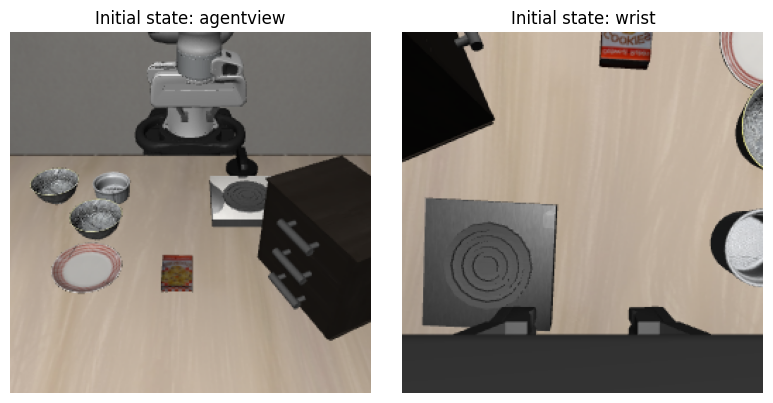

In [ ]:
env.reset()
raw_obs = env.set_init_state(init_states[INIT_STATE_ID])

print("Task:", task_description)
print("Observation keys:", list(raw_obs.keys()))

show_two_cameras(raw_obs, title_prefix="Initial state")

In [ ]:
raw_obs.keys()

odict_keys(['robot0_joint_pos', 'robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'agentview_image', 'robot0_eye_in_hand_image', 'akita_black_bowl_1_pos', 'akita_black_bowl_1_quat', 'akita_black_bowl_1_to_robot0_eef_pos', 'akita_black_bowl_1_to_robot0_eef_quat', 'akita_black_bowl_2_pos', 'akita_black_bowl_2_quat', 'akita_black_bowl_2_to_robot0_eef_pos', 'akita_black_bowl_2_to_robot0_eef_quat', 'cookies_1_pos', 'cookies_1_quat', 'cookies_1_to_robot0_eef_pos', 'cookies_1_to_robot0_eef_quat', 'glazed_rim_porcelain_ramekin_1_pos', 'glazed_rim_porcelain_ramekin_1_quat', 'glazed_rim_porcelain_ramekin_1_to_robot0_eef_pos', 'glazed_rim_porcelain_ramekin_1_to_robot0_eef_quat', 'plate_1_pos', 'plate_1_quat', 'plate_1_to_robot0_eef_pos', 'plate_1_to_robot0_eef_quat', 'robot0_proprio-state', 'object-state'])

Predicted action shape: (7,)
Predicted action: [ 0.6383084   0.595664   -0.03715302  0.0014384  -0.0243751   0.01802269
 -0.9901337 ]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Reward: 0.0
Done: False
Info: {}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


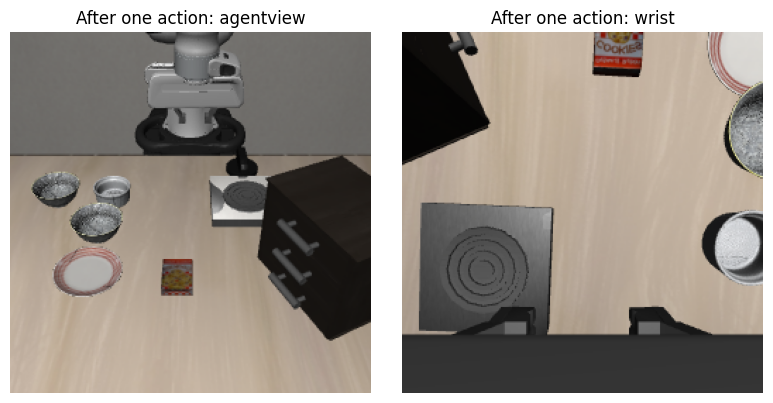

In [ ]:
policy.reset()

action = predict_action(raw_obs, task_description)
print("Predicted action shape:", action.shape)
print("Predicted action:", action)

next_obs, reward, done, info = env.step(action.tolist())
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

show_two_cameras(next_obs, title_prefix="After one action")

### Full Rolout

In [ ]:
policy.reset()

env.reset()
raw_obs = env.set_init_state(init_states[INIT_STATE_ID])

saved_frames = []
saved_steps = []

saved_frames.append(rotate_180(raw_obs["agentview_image"]))
saved_steps.append(0)

success = False
episode_reward = 0.0
FRAME_EVERY=True

for t in range(MAX_STEPS + NUM_STABILIZATION_STEPS):
    if t < NUM_STABILIZATION_STEPS:
        action = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0]
    else:
        action = predict_action(raw_obs, task_description).tolist()

    raw_obs, reward, done, info = env.step(action)
    episode_reward += float(reward)

    if (t + 1) % FRAME_EVERY == 0 or done:
        saved_frames.append(rotate_180(raw_obs["agentview_image"]))
        saved_steps.append(t + 1)

    if done:
        success = True
        break

print(f"Episode finished after {t + 1} steps")
print("Success:", success)
print("Episode reward:", episode_reward)
print("Final info:", info)

Episode finished after 88 steps
Success: True
Episode reward: 1.0
Final info: {}


In [ ]:
import imageio
from IPython.display import Video, display
from pathlib import Path

video_path = Path("smolvla_libero_rollout.mp4")

with imageio.get_writer(video_path, fps=30) as writer:
    for frame in saved_frames:
        writer.append_data(frame)

print(f"Saved video to: {video_path}")

display(Video(str(video_path), embed=True))

Saved video to: smolvla_libero_rollout.mp4


# Deep dive into SmolVLA

In [ ]:
import os
import json
import math
import inspect
import textwrap
from pathlib import Path
from pprint import pprint

import numpy as np
import torch
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download

from lerobot.configs.policies import PreTrainedConfig
from lerobot.policies.factory import make_pre_post_processors
from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy

MODEL_ID = "HuggingFaceVLA/smolvla_libero"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

policy_cfg = PreTrainedConfig.from_pretrained(MODEL_ID)
pprint(policy_cfg)

policy = SmolVLAPolicy.from_pretrained(MODEL_ID)
policy.to(device)
policy.eval()
policy.reset()

Using device: cuda
SmolVLAConfig(n_obs_steps=1,
              input_features={'observation.images.image': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>,
                                                                        shape=(3,
                                                                               256,
                                                                               256)),
                              'observation.images.image2': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>,
                                                                         shape=(3,
                                                                                256,
                                                                                256)),
                              'observation.state': PolicyFeature(type=<FeatureType.STATE: 'STATE'>,
                                                                 shape=(8,))},
              output_features={'action': Policy

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

In [ ]:
# policy.model.vlm_with_expert.vlm

In [ ]:
# policy.model.vlm_with_expert.lm_expert

In [ ]:
preprocessor_overrides = {
    "device_processor": {"device": str(device)},
    "rename_observations_processor": {"rename_map": {}},
}

preprocessor, postprocessor = make_pre_post_processors(
    policy_cfg=policy_cfg,
    pretrained_path=MODEL_ID,
    preprocessor_overrides=preprocessor_overrides,
)

In [ ]:
env.reset()
raw_obs = env.set_init_state(init_states[0])

In [ ]:
raw_obs.keys()

odict_keys(['robot0_joint_pos', 'robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'agentview_image', 'robot0_eye_in_hand_image', 'akita_black_bowl_1_pos', 'akita_black_bowl_1_quat', 'akita_black_bowl_1_to_robot0_eef_pos', 'akita_black_bowl_1_to_robot0_eef_quat', 'akita_black_bowl_2_pos', 'akita_black_bowl_2_quat', 'akita_black_bowl_2_to_robot0_eef_pos', 'akita_black_bowl_2_to_robot0_eef_quat', 'cookies_1_pos', 'cookies_1_quat', 'cookies_1_to_robot0_eef_pos', 'cookies_1_to_robot0_eef_quat', 'glazed_rim_porcelain_ramekin_1_pos', 'glazed_rim_porcelain_ramekin_1_quat', 'glazed_rim_porcelain_ramekin_1_to_robot0_eef_pos', 'glazed_rim_porcelain_ramekin_1_to_robot0_eef_quat', 'plate_1_pos', 'plate_1_quat', 'plate_1_to_robot0_eef_pos', 'plate_1_to_robot0_eef_quat', 'robot0_proprio-state', 'object-state'])

In [ ]:
task_description

'pick up the black bowl between the plate and the ramekin and place it on the plate'

In [ ]:
agent_img = rotate_180(raw_obs["agentview_image"])
wrist_img = rotate_180(raw_obs["robot0_eye_in_hand_image"])

eef_pos = raw_obs["robot0_eef_pos"].astype(np.float32)
eef_quat = raw_obs["robot0_eef_quat"].astype(np.float32)
gripper_qpos = raw_obs["robot0_gripper_qpos"].astype(np.float32)

eef_axisangle = quat2axisangle(eef_quat)
state = np.concatenate([eef_pos, eef_axisangle, gripper_qpos], axis=0).astype(np.float32)

standard_obs = {
    "observation.images.image": torch.from_numpy(agent_img).permute(2, 0, 1).unsqueeze(0).float() / 255.0,
    "observation.images.image2": torch.from_numpy(wrist_img).permute(2, 0, 1).unsqueeze(0).float() / 255.0,
    "observation.state": torch.from_numpy(state).unsqueeze(0).float(),
    "task": [task_description],
}

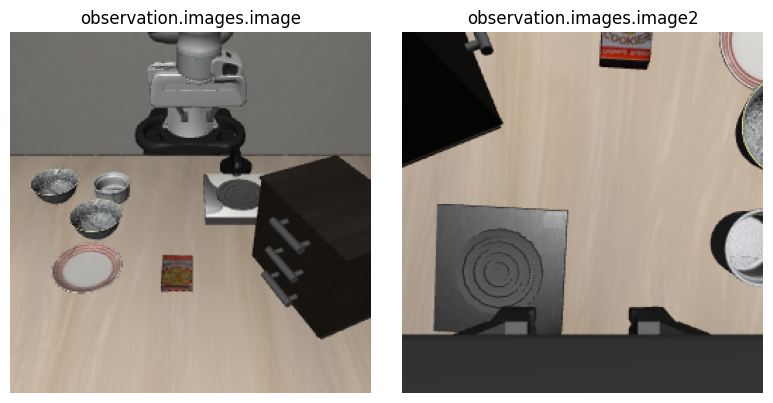

Task text:
pick up the black bowl between the plate and the ramekin and place it on the plate

8D state sent to the model:
[-0.21081486 -0.01515982  1.1756772   3.1511967  -0.08390412 -0.07118981
  0.020833   -0.020833  ]


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(agent_img)
axes[0].set_title("observation.images.image")
axes[0].axis("off")

axes[1].imshow(wrist_img)
axes[1].set_title("observation.images.image2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Task text:")
print(task_description)

print("\n8D state sent to the model:")
print(standard_obs["observation.state"][0].cpu().numpy())

### Preprocessing

In [ ]:
current = {
    'observation': standard_obs,
    'action': None,
    'reward': 0.0,
    'done': False,
    'truncated': False,
    'info': {},
    'complementary_data': {
        "task": task_description,
    },
}

steps = preprocessor.steps

print("\nNumber of preprocessor steps:", len(steps))


Number of preprocessor steps: 6


In [ ]:
steps

[RenameObservationsProcessorStep(rename_map={}),
 AddBatchDimensionProcessorStep(to_batch_action_processor=AddBatchDimensionActionStep(), to_batch_observation_processor=AddBatchDimensionObservationStep(), to_batch_complementary_data_processor=AddBatchDimensionComplementaryDataStep()),
 TokenizerProcessorStep(tokenizer_name='HuggingFaceTB/SmolVLM2-500M-Instruct', tokenizer=None, max_length=48, task_key='task', padding_side='right', padding='longest', truncation=True),
 DeviceProcessorStep(device='cuda', float_dtype=None),
 NormalizerProcessorStep(features={'observation.images.image': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 256, 256)), 'observation.images.image2': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 256, 256)), 'observation.state': PolicyFeature(type=<FeatureType.STATE: 'STATE'>, shape=(8,)), 'action': PolicyFeature(type=<FeatureType.ACTION: 'ACTION'>, shape=(7,))}, norm_map={<FeatureType.VISUAL: 'VISUAL'>: <NormalizationMode.IDENTITY: 'IDENT

In [ ]:


for i, step in enumerate(steps):
    print("\n" + "=" * 200)
    print(f"Step {i}: {step.__class__.__name__}")
    print(step)

    current = step(current)

    obs = current['observation']
    comp = current['complementary_data']


    for k, v in obs.items():
        if isinstance(v, torch.Tensor):
            msg = f"  {k}: {tuple(v.shape)=}, dtype={v.dtype}, device={v.device}"
            msg += f", min={float(v.min()):.4f}, max={float(v.max()):.4f}"
            print(msg)
        else:
            print(f"  {k}: type={type(v)}, value={v}")

    print("\nComplementary data:")
    print(comp)

processed_obs = current['observation']

print("\n" + "=" * 80)
print("Final processed observation keys:")
print(list(processed_obs.keys()))


Step 0: RenameObservationsProcessorStep
RenameObservationsProcessorStep(rename_map={})
  observation.images.image: tuple(v.shape)=(1, 3, 256, 256), dtype=torch.float32, device=cpu, min=0.0196, max=0.9725
  observation.images.image2: tuple(v.shape)=(1, 3, 256, 256), dtype=torch.float32, device=cpu, min=0.0039, max=0.9373
  observation.state: tuple(v.shape)=(1, 8), dtype=torch.float32, device=cpu, min=-0.2108, max=3.1512
  task: type=<class 'list'>, value=['pick up the black bowl between the plate and the ramekin and place it on the plate']

Complementary data:
{'task': 'pick up the black bowl between the plate and the ramekin and place it on the plate'}

Step 1: AddBatchDimensionProcessorStep
AddBatchDimensionProcessorStep(to_batch_action_processor=AddBatchDimensionActionStep(), to_batch_observation_processor=AddBatchDimensionObservationStep(), to_batch_complementary_data_processor=AddBatchDimensionComplementaryDataStep())
  observation.images.image: tuple(v.shape)=(1, 3, 256, 256), dt

### Action Prediction

In [ ]:
# policy.reset()

# with torch.inference_mode():
#     raw_action = policy.select_action(processed_obs)

# print("Type of raw_action:", type(raw_action))

# if isinstance(raw_action, torch.Tensor):
#     print("raw_action shape:", tuple(raw_action.shape))
#     print("raw_action dtype:", raw_action.dtype)
#     print("raw_action device:", raw_action.device)
#     print("raw_action values:")
#     print(raw_action.detach().cpu().numpy())
# else:
#     print(raw_action)

### More detailed action prediction

https://github.com/huggingface/lerobot/blob/main/src/lerobot/policies/smolvla/modeling_smolvla.py

In [ ]:
policy.reset() # reset action queues

print("policy._queues keys:")
print(policy._queues.keys())

print("\nAction queue length right after reset:")
print(len(policy._queues["action"]))

policy._queues keys:
dict_keys(['action'])

Action queue length right after reset:
0


#### step 1: prepeare batch

In [ ]:
batch = {}
for k, v in processed_obs.items():
    batch[k] = v

print("Input batch keys:")
print(list(batch.keys()))

prepared_batch = policy._prepare_batch(batch)

Input batch keys:
['observation.images.image', 'observation.images.image2', 'observation.state', 'task', 'observation.language.tokens', 'observation.language.attention_mask']


#### step 2: populate queues manually

In [ ]:
from lerobot.policies.utils import populate_queues

policy.reset()

print("Before populate_queues:")
print("action queue length:", len(policy._queues["action"]))

policy._queues = populate_queues(policy._queues, prepared_batch, exclude_keys=["action"])

print("\nAfter populate_queues:")
print("action queue length:", len(policy._queues["action"]))
print("queue object:", policy._queues["action"])

Before populate_queues:
action queue length: 0

After populate_queues:
action queue length: 0
queue object: deque([], maxlen=1)


#### step 3: prepeare images and state

In [ ]:


images, img_masks = policy.prepare_images(prepared_batch)
state = policy.prepare_state(prepared_batch)
print(state.detach().cpu().numpy())

[[-1.5655601  -0.3266135   1.0861468   0.51989853  0.15057737  0.16715103
  -0.4289849   0.45222467  0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]]


In [ ]:
state.shape

torch.Size([1, 32])

In [ ]:
# let's check language tokens and masks

lang_tokens = prepared_batch["observation.language.tokens"]
lang_masks = prepared_batch["observation.language.attention_mask"]

print("lang_tokens shape:", tuple(lang_tokens.shape))
print("lang_tokens dtype:", lang_tokens.dtype)
print("lang_masks shape:", tuple(lang_masks.shape))
print("lang_masks dtype:", lang_masks.dtype)

print("\nFirst token ids:")
print(lang_tokens[0, :40].detach().cpu().numpy())

print("\nFirst attention mask values:")
print(lang_masks[0, :40].detach().cpu().numpy())

lang_tokens shape: (1, 20)
lang_tokens dtype: torch.int64
lang_masks shape: (1, 20)
lang_masks dtype: torch.bool

First token ids:
[18188   614   260  2632 12505   826   260  6496   284   260   689  1558
  7109   284  1379   357   335   260  6496   198]

First attention mask values:
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True]


#### step 4: embed prefix

In [ ]:


prefix_embs, prefix_pad_masks, prefix_att_masks = policy.model.embed_prefix(
    images,
    img_masks,
    lang_tokens,
    lang_masks,
    state=state,
)

print("prefix_embs shape:", tuple(prefix_embs.shape))
print("prefix_pad_masks shape:", tuple(prefix_pad_masks.shape))
print("prefix_att_masks shape:", tuple(prefix_att_masks.shape))

print("\nprefix_embs dtype:", prefix_embs.dtype)
print("prefix_embs device:", prefix_embs.device)

print("\nFirst 20 prefix_pad_masks values:")
print(prefix_pad_masks[0, :20].detach().cpu().numpy())

print("\nFirst 20 prefix_att_masks values:")
print(prefix_att_masks[0, :20].detach().cpu().numpy())

prefix_embs shape: (1, 149, 960)
prefix_pad_masks shape: (1, 149)
prefix_att_masks shape: (1, 149)

prefix_embs dtype: torch.float32
prefix_embs device: cuda:0

First 20 prefix_pad_masks values:
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True]

First 20 prefix_att_masks values:
[False False False False False False False False False False False False
 False False False False False False False False]


#### step 5: build prefix 2D attention mask


In [ ]:

from lerobot.policies.smolvla.modeling_smolvla import make_att_2d_masks

prefix_att_2d_masks = make_att_2d_masks(prefix_pad_masks, prefix_att_masks)
prefix_position_ids = torch.cumsum(prefix_pad_masks, dim=1) - 1

print("prefix_att_2d_masks shape:", tuple(prefix_att_2d_masks.shape))
print("prefix_position_ids shape:", tuple(prefix_position_ids.shape))

print("\nSmall top-left corner of attention mask:")
print(prefix_att_2d_masks[0, :12, :12].detach().cpu().numpy().astype(int))

print("\nFirst 30 position ids:")
print(prefix_position_ids[0, :30].detach().cpu().numpy())

prefix_att_2d_masks shape: (1, 149, 149)
prefix_position_ids shape: (1, 149)

Small top-left corner of attention mask:
[[1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1]]

First 30 position ids:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]


#### viz prefix 2D attention mask

In [ ]:
print("add_image_special_tokens:", policy.model.add_image_special_tokens)

num_cameras = len(images)
print("num_cameras:", num_cameras)

image_token_lengths = []
image_block_names = []
image_block_lengths = []

for i in range(num_cameras):
    img_emb = policy.model.vlm_with_expert.embed_image(images[i])
    img_len = img_emb.shape[1]
    image_token_lengths.append(img_len)

    if policy.model.add_image_special_tokens:
        image_block_names.append(f"cam{i}_start")
        image_block_lengths.append(2)

    image_block_names.append(f"cam{i}_img")
    image_block_lengths.append(img_len)

    if policy.model.add_image_special_tokens:
        image_block_names.append(f"cam{i}_end")
        image_block_lengths.append(1)

lang_len = lang_tokens.shape[1]
state_len = 1 if state.ndim == 2 else state.shape[1]

image_block_names.append("language")
image_block_lengths.append(lang_len)

image_block_names.append("state")
image_block_lengths.append(state_len)

real_prefix_len = sum(image_block_lengths)
full_prefix_len = prefix_att_2d_masks.shape[-1]
pad_len = full_prefix_len - real_prefix_len

if pad_len > 0:
    image_block_names.append("padding")
    image_block_lengths.append(pad_len)

print("Block names:")
print(image_block_names)

print("\nBlock lengths:")
print(image_block_lengths)

print("\nreal_prefix_len:", real_prefix_len)
print("full_prefix_len:", full_prefix_len)
print("pad_len:", pad_len)

add_image_special_tokens: False
num_cameras: 2
Block names:
['cam0_img', 'cam1_img', 'language', 'state']

Block lengths:
[64, 64, 20, 1]

real_prefix_len: 149
full_prefix_len: 149
pad_len: 0


In [ ]:
# token index ranges for blocks

start = 0
block_ranges = []

for name, length in zip(image_block_names, image_block_lengths):
    end = start + length
    block_ranges.append((name, start, end))
    print(f"{name:12s} -> [{start:4d}, {end:4d})  len={length}")
    start = end

cam0_img     -> [   0,   64)  len=64
cam1_img     -> [  64,  128)  len=64
language     -> [ 128,  148)  len=20
state        -> [ 148,  149)  len=1


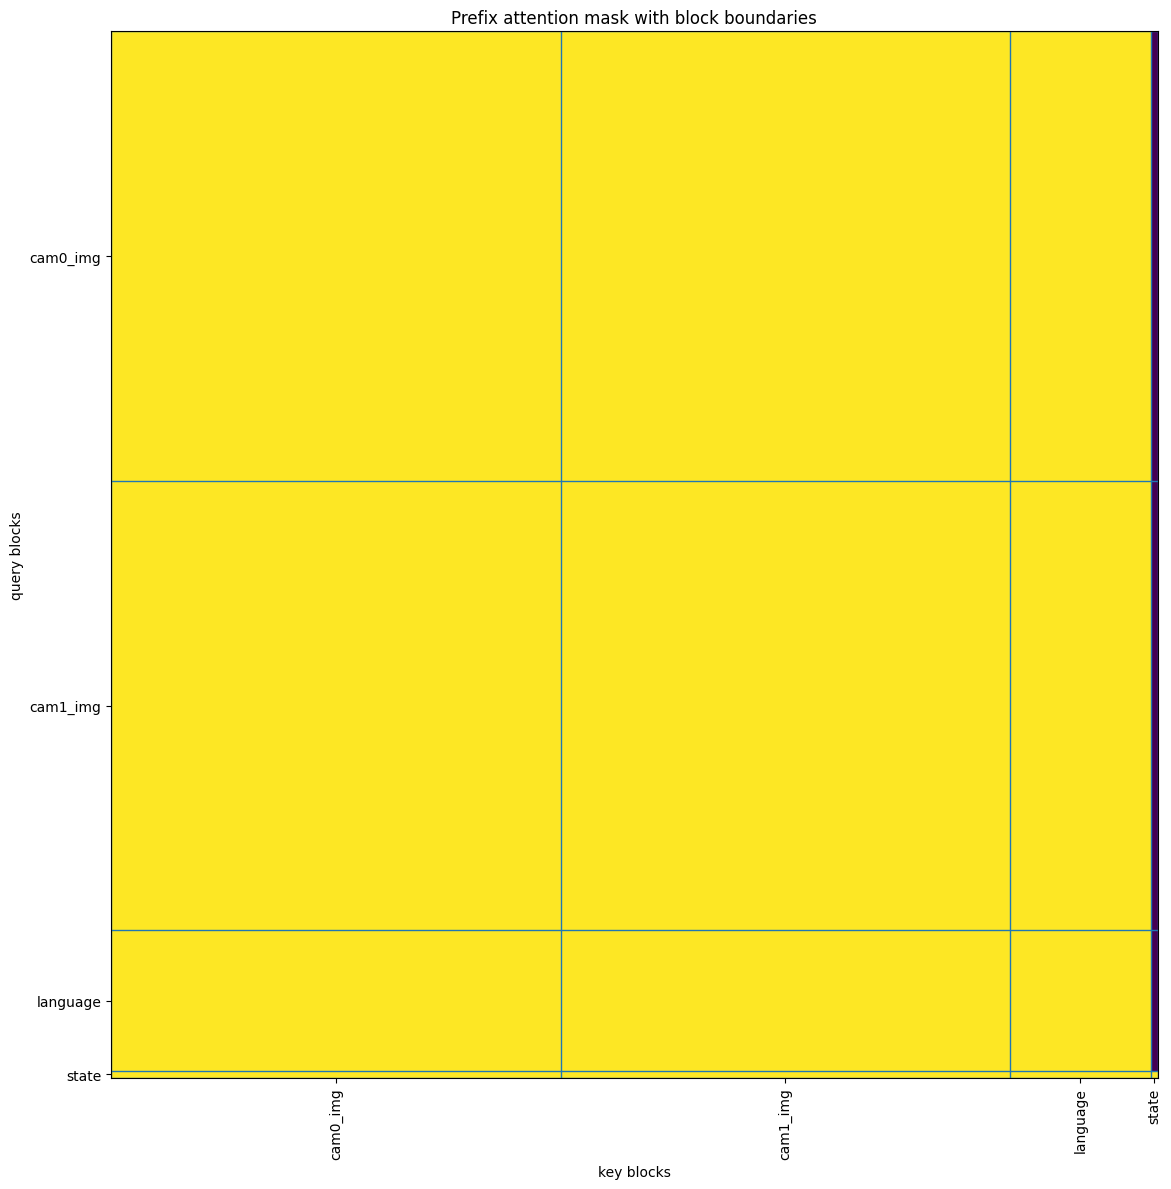

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# full mask with block boundaries

mask_np = prefix_att_2d_masks[0].detach().cpu().numpy().astype(int)

plt.figure(figsize=(12, 12))
plt.imshow(mask_np)

for name, start, end in block_ranges:
    plt.axvline(start - 0.5, linewidth=1)
    plt.axhline(start - 0.5, linewidth=1)

plt.axvline(full_prefix_len - 0.5, linewidth=1)
plt.axhline(full_prefix_len - 0.5, linewidth=1)

centers = []
labels = []
for name, start, end in block_ranges:
    centers.append((start + end - 1) / 2)
    labels.append(name)

plt.xticks(centers, labels, rotation=90)
plt.yticks(centers, labels)

plt.title("Prefix attention mask with block boundaries")
plt.xlabel("key blocks")
plt.ylabel("query blocks")
plt.tight_layout()
plt.show()

In [ ]:
# inspect selected sub-blocks

mask_np = prefix_att_2d_masks[0].detach().cpu().numpy().astype(int)

name_to_range = {}
for name, start, end in block_ranges:
    name_to_range[name] = (start, end)

lang_start, lang_end = name_to_range["language"]
state_start, state_end = name_to_range["state"]

print("language -> language")
print(mask_np[lang_start:lang_end, lang_start:lang_end])

print("\nlanguage -> state")
print(mask_np[lang_start:lang_end, state_start:state_end])

print("\nstate -> language")
print(mask_np[state_start:state_end, lang_start:lang_end])

print("\nstate -> state")
print(mask_np[state_start:state_end, state_start:state_end])

language -> language
[[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]

language -> state
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]

In [ ]:
–

#### step 6: run prefix forward and get KV cache


In [ ]:

with torch.inference_mode():
    prefix_outputs, past_key_values = policy.model.vlm_with_expert.forward(
        attention_mask=prefix_att_2d_masks,
        position_ids=prefix_position_ids,
        past_key_values=None,
        inputs_embeds=[prefix_embs, None],
        use_cache=policy.config.use_cache,
        fill_kv_cache=True,
    )

print("Number of cache layers:", len(past_key_values))

Number of cache layers: 32


#### step 7: sample initial noise for actions

**Flow-matching inference loop**

At inference time, the model starts from Gaussian noise and iteratively transforms it into a predicted action chunk. In the notation of the paper, the model predicts a vector field

$$
v_\theta(A_t^\tau, o_t),
$$

where:

- $o_t$ is the current observation,
- $A_t^\tau$ is the current noisy action chunk at time $\tau$.


In [ ]:


bsize = state.shape[0]
device_now = state.device

actions_shape = (bsize, policy.config.chunk_size, policy.config.max_action_dim)
x_t = policy.model.sample_noise(actions_shape, device_now)

print("Initial noise x_t:")
print("shape:", tuple(x_t.shape))

Initial noise x_t:
shape: (1, 50, 32)


Here, `x_t` is the current noisy action chunk.  
This corresponds to initializing the action chunk from Gaussian noise:

$$
A_t^0 \sim \mathcal{N}(0, I).
$$


#### step 8.1: run one denoising step manually


In [ ]:

time = 1.0
time_tensor = torch.tensor(time, dtype=torch.float32, device=device_now).expand(bsize)

with torch.inference_mode():
    v_t = policy.model.denoise_step(
        prefix_pad_masks=prefix_pad_masks,
        past_key_values=past_key_values,
        x_t=x_t,
        timestep=time_tensor,
    )

print("v_t shape:", tuple(v_t.shape))
print("v_t dtype:", v_t.dtype)
print("v_t device:", v_t.device)
print("v_t min:", float(v_t.min()))
print("v_t max:", float(v_t.max()))
print("v_t mean:", float(v_t.mean()))

v_t shape: (1, 50, 32)
v_t dtype: torch.float32
v_t device: cuda:0
v_t min: -3.790489435195923
v_t max: 3.4820556640625
v_t mean: -0.010996401309967041


At each iteration, the model takes the current noisy action chunk $A_t^\tau$ and predicts the denoising vector field

$$
v_t = v_\theta(A_t^\tau, o_t).
$$

This vector tells the model how to move the current noisy sample toward a clean action chunk.

#### step 8.2: one Euler update of x_t


In [ ]:
num_steps = policy.config.num_steps
dt = -1.0 / num_steps

In [ ]:
num_steps

10

We use an Euler-style integration update. The step size is

$$
\delta = -\frac{1}{N},
$$

where $N = \text{num_steps}$. The negative sign appears because the implementation starts from the noisy end and moves backward through the denoising schedule.

In [ ]:


x_t_next = x_t + dt * v_t

print("dt =", dt)

print("\nBefore update:")
print("x_t mean =", float(x_t.mean()))
print("x_t std  =", float(x_t.std()))

print("\nAfter update:")
print("x_t_next mean =", float(x_t_next.mean()))
print("x_t_next std  =", float(x_t_next.std()))

dt = -0.1

Before update:
x_t mean = -0.007791232317686081
x_t std  = 0.9689494967460632

After update:
x_t_next mean = -0.006691592279821634
x_t_next std  = 0.8733132481575012


Euler integration step:

$$
A_t^\tau \leftarrow A_t^\tau + \delta \, v_\theta(A_t^\tau, o_t).
$$

After each iteration, the action chunk becomes a little less noisy. The loop repeats this denoising update `num_steps` times.  
After the final step, `x_t` contains the predicted action chunk:

$$
A_t = [a_t, a_{t+1}, \dots, a_{t+H-1}].
$$

#### step 8.3 full denoising loop manually


In [ ]:

bsize = state.shape[0]
device_now = state.device

actions_shape = (bsize, policy.config.chunk_size, policy.config.max_action_dim)
x_t = policy.model.sample_noise(actions_shape, device_now)

num_steps = policy.config.num_steps
dt = -1.0 / num_steps

history = []

with torch.inference_mode():
    for step_idx in range(num_steps):
        time = 1.0 + step_idx * dt
        time_tensor = torch.tensor(time, dtype=torch.float32, device=device_now).expand(bsize)

        v_t = policy.model.denoise_step(
            prefix_pad_masks=prefix_pad_masks,
            past_key_values=past_key_values,
            x_t=x_t,
            timestep=time_tensor,
        )

        x_t = x_t + dt * v_t

        history.append([
            step_idx,
            float(time),
            float(x_t.mean()),
            float(x_t.std()),
            float(v_t.mean()),
            float(v_t.std()),
        ])

print("Final x_t shape:", tuple(x_t.shape))
print("Final action chunk tensor:")
print(x_t.detach().cpu().numpy())

Final x_t shape: (1, 50, 32)
Final action chunk tensor:
[[[ 2.2717619e+00  7.1430600e-01  3.5726646e-01 ...  1.3173178e-02
    1.7785579e-03  1.0274552e-02]
  [ 2.1216078e+00  9.4038063e-01  1.9110990e-01 ... -9.5641613e-04
    6.0551018e-03 -1.1971146e-03]
  [ 2.0153418e+00  1.0766156e+00  2.0794095e-01 ...  1.3351664e-03
   -5.7764128e-03  3.5624206e-03]
  ...
  [ 2.1622016e-01  7.5855911e-02  8.2285750e-01 ...  2.5961474e-03
    2.8153062e-03  3.4236722e-04]
  [ 4.0483841e-01  2.9443860e-01  1.0336573e+00 ...  6.4098835e-03
    5.8818758e-03 -8.1579573e-03]
  [ 3.3041778e-01  3.6363187e-01  1.0706960e+00 ...  8.4140003e-03
    5.8183335e-03  6.9858134e-04]]]


#### step 9: unpad action chunk to original action dim


In [ ]:
original_action_dim = policy.config.action_feature.shape[0]
actions_unpadded = x_t[:, :, :original_action_dim]


print("x_t shape:", x_t.shape)
print("actions_unpadded shape:", tuple(actions_unpadded.shape))

x_t shape: torch.Size([1, 50, 32])
actions_unpadded shape: (1, 50, 7)


### Why x_t.shape != actions_unpadded.shape? And why 32?

SmolVLA predicts in a shared 32D internal action space for **cross-embodiment compatibility**, then trims the output back to the real robot/environment action dimension such as 7 for LIBERO.

#### step 10: put actions into policy queue



In [ ]:

policy.reset()

print("Queue length right after reset:")
print(len(policy._queues["action"]))

print("\nQueue content right after reset:")
print(list(policy._queues["action"]))

policy._queues["action"].extend(
    actions_for_queue[: policy.config.n_action_steps]
)

print("\nQueue length after extend:")
print(len(policy._queues["action"]))

print("\nQueue element 0:")
print(policy._queues["action"][0].detach().cpu().numpy())

print("\nQueue element 1:")
print(policy._queues["action"][1].detach().cpu().numpy())

Queue length right after reset:
0

Queue content right after reset:
[]

Queue length after extend:
1

Queue element 0:
[[ 1.8269356  -0.1067625   0.9814196   0.01079514  2.3215642   0.5889697
  -0.92527735]]

Queue element 1:


IndexError: deque index out of range

In [ ]:
policy.config.n_action_steps

1

In [ ]:
policy.config.chunk_size

50

### Why n_action_steps < chunk_size?

*	**chunk_size** is the prediction horizon
*	**n_action_steps** is the execution horizon

Why do this?

* A larger chunk can give **smoother, more temporally consistent motion** because the model predicts a short trajectory rather than isolated one-step actions.
* A smaller execution horizon **keeps the policy reactive**, so it can correct for object motion, camera changes, or accumulated control error instead of blindly following an old long plan.

### Action Post Processing

In [ ]:
from lerobot.processor.pipeline import TransitionKey

current_post = {
    TransitionKey.OBSERVATION: None,
    TransitionKey.ACTION: raw_action,
    TransitionKey.REWARD: 0.0,
    TransitionKey.DONE: False,
    TransitionKey.TRUNCATED: False,
    TransitionKey.INFO: {},
    TransitionKey.COMPLEMENTARY_DATA: {},
}

post_steps = None
for attr in ["steps", "_steps", "processors", "_processors"]:
    if hasattr(postprocessor, attr):
        value = getattr(postprocessor, attr)
        if isinstance(value, (list, tuple)):
            post_steps = list(value)
            break

print("Number of postprocessor steps:", len(post_steps))

for i, step in enumerate(post_steps):
    print("\n" + "=" * 80)
    print(f"Step {i}: {step.__class__.__name__}")
    print(step)

    current_post = step(current_post)

    print("\nTransition keys after this step:")
    print(list(current_post.keys()))

    action_now = current_post[TransitionKey.ACTION]

    if isinstance(action_now, torch.Tensor):
        print("Action tensor info:")
        print("  shape:", tuple(action_now.shape))
        print("  dtype:", action_now.dtype)
        print("  device:", action_now.device)
        print("  values:")
        print(action_now.detach().cpu().numpy())
    else:
        print("Action type:", type(action_now))
        print(action_now)


In [ ]:
env_action = current_post[TransitionKey.ACTION]

print("\nFinal env_action:")
if isinstance(env_action, torch.Tensor):
    print(env_action.detach().cpu().numpy())
else:
    print(env_action)

print("RAW ACTION:")
if isinstance(raw_action, torch.Tensor):
    print(raw_action.detach().cpu().numpy())
else:
    print(raw_action)

print("\nPOSTPROCESSED ENV ACTION:")
if isinstance(env_action, torch.Tensor):
    print(env_action.detach().cpu().numpy())
else:
    print(env_action)

### Execute one action

In [ ]:
env.reset()
raw_obs = env.set_init_state(init_states[0])

before_frame = rotate_180(raw_obs["agentview_image"])

agent_img = rotate_180(raw_obs["agentview_image"])
wrist_img = rotate_180(raw_obs["robot0_eye_in_hand_image"])

eef_pos = raw_obs["robot0_eef_pos"].astype(np.float32)
eef_quat = raw_obs["robot0_eef_quat"].astype(np.float32)
gripper_qpos = raw_obs["robot0_gripper_qpos"].astype(np.float32)

eef_axisangle = quat2axisangle(eef_quat)
state = np.concatenate([eef_pos, eef_axisangle, gripper_qpos], axis=0).astype(np.float32)

standard_obs = {
    "observation.images.image": torch.from_numpy(agent_img).permute(2, 0, 1).float() / 255.0,
    "observation.images.image2": torch.from_numpy(wrist_img).permute(2, 0, 1).float() / 255.0,
    "observation.state": torch.from_numpy(state).float(),
}

from lerobot.processor.pipeline import TransitionKey

current = {
    TransitionKey.OBSERVATION: standard_obs,
    TransitionKey.ACTION: None,
    TransitionKey.REWARD: 0.0,
    TransitionKey.DONE: False,
    TransitionKey.TRUNCATED: False,
    TransitionKey.INFO: {},
    TransitionKey.COMPLEMENTARY_DATA: {"task": task_description},
}

for step in steps:
    current = step(current)

processed_obs = current[TransitionKey.OBSERVATION]

policy.reset()

with torch.inference_mode():
    raw_action = policy.select_action(processed_obs)

current_post = {
    TransitionKey.OBSERVATION: None,
    TransitionKey.ACTION: raw_action,
    TransitionKey.REWARD: 0.0,
    TransitionKey.DONE: False,
    TransitionKey.TRUNCATED: False,
    TransitionKey.INFO: {},
    TransitionKey.COMPLEMENTARY_DATA: {},
}

for step in post_steps:
    current_post = step(current_post)

env_action = current_post[TransitionKey.ACTION]

if isinstance(env_action, torch.Tensor):
    env_action_np = env_action.squeeze(0).detach().cpu().numpy().astype(np.float32)
else:
    env_action_np = np.array(env_action, dtype=np.float32)

print("Action sent to env:")
print(env_action_np)

next_obs, reward, done, info = env.step(env_action_np.tolist())

after_frame = rotate_180(next_obs["agentview_image"])

print("\nReward:", reward)
print("Done:", done)
print("Info:", info)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(before_frame)
axes[0].set_title("Before action")
axes[0].axis("off")

axes[1].imshow(after_frame)
axes[1].set_title("After action")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# VLM still able to predict text

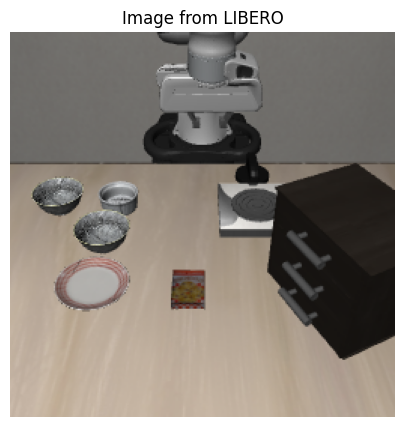

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

env.reset()
raw_obs = env.set_init_state(init_states[0])

img = rotate_180(raw_obs["agentview_image"])
pil_img = Image.fromarray(img)

plt.figure(figsize=(5, 5))
plt.imshow(pil_img)
plt.axis("off")
plt.title("Image from LIBERO")
plt.show()

In [ ]:

from transformers import AutoProcessor
import torch

# internal vision-language model inside SmolVLA
vlm = policy.model.vlm_with_expert.vlm
vlm.eval()
vlm.to(device)

# processor for the base SmolVLM model
vlm_processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM2-500M-Instruct")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Describe what the robot sees on the table in one short sentence."}
        ]
    }
]

prompt = vlm_processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = vlm_processor(
    text=prompt,
    images=pil_img,
    return_tensors="pt"
)

inputs = {k: v.to(device) if hasattr(v, "to") else v for k, v in inputs.items()}

with torch.inference_mode():
    generated_ids = vlm.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=False
    )

prompt_len = inputs["input_ids"].shape[1]
new_tokens = generated_ids[:, prompt_len:]

answer = vlm_processor.batch_decode(
    new_tokens,
    skip_special_tokens=True
)[0]

print("Model answer:")
print(answer)

Model answer:
 A bowl of cereal, a bowl of cereal, and a box of cereal.
